In [2]:
import os
print(os.listdir('/kaggle/input/datasets/nayanpokharel/plant-leaf-diseases-wa/Plant_leave_diseases_dataset_without_augmentation'))

['Tomato___Late_blight', 'Tomato___healthy', 'Background_without_leaves', 'Potato___healthy', 'Tomato___Early_blight', 'Tomato___Septoria_leaf_spot', 'Strawberry___Leaf_scorch', 'Apple___Apple_scab', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Bacterial_spot', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Tomato___Target_Spot', 'Potato___Late_blight', 'Tomato___Tomato_mosaic_virus', 'Strawberry___healthy', 'Apple___healthy', 'Potato___Early_blight', 'Tomato___Leaf_Mold', 'Tomato___Spider_mites Two-spotted_spider_mite']


In [3]:
import subprocess
print(subprocess.run(['nvidia-smi'], capture_output=True, text=True).stdout)


Fri May 29 11:41:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
import os, random, itertools, json, warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_fscore_support, roc_curve, auc)
from sklearn.preprocessing import label_binarize

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

tf.keras.mixed_precision.set_global_policy('mixed_float16')
print('Mixed precision :', tf.keras.mixed_precision.global_policy().compute_dtype)
print('TensorFlow      :', tf.__version__)
print('GPUs            :', tf.config.list_physical_devices('GPU'))


2026-05-29 11:41:53.412319: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780054913.596169      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780054913.657956      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780054914.101295      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780054914.101332      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780054914.101336      58 computation_placer.cc:177] computation placer alr

Mixed precision : float16
TensorFlow      : 2.19.0
GPUs            : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [5]:
DATA_DIR        = '/kaggle/input/datasets/nayanpokharel/plant-leaf-diseases-wa/Plant_leave_diseases_dataset_without_augmentation'
CHECKPOINT_DIR  = '/kaggle/working/checkpoints'
BEST_MODEL_PATH = '/kaggle/working/plant_best_model.keras'

IMG_SIZE     = 224
IMG_SHAPE    = (IMG_SIZE, IMG_SIZE, 3)
BATCH_SIZE   = 16
VAL_SPLIT    = 0.15
TEST_SPLIT   = 0.10

P1_LR        = 1e-3
P1_EPOCHS    = 20
P2_LR        = 5e-5
P2_EPOCHS    = 80
WEIGHT_DECAY = 1e-4
UNFREEZE_TOP = 100

AUTOTUNE = tf.data.AUTOTUNE
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print('Config ready.')


Config ready.


In [6]:
CLASS_ORIGINAL = {
    'Apple___Apple_scab': 630,
    'Apple___Black_rot': 621,
    'Apple___Cedar_apple_rust': 275,
    'Apple___healthy': 1645,
    'Background_without_leaves': 1143,
    'Potato___Early_blight': 1000,
    'Potato___Late_blight': 1000,
    'Potato___healthy': 152,
    'Strawberry___Leaf_scorch': 1109,
    'Strawberry___healthy': 456,
    'Tomato___Bacterial_spot': 2127,
    'Tomato___Early_blight': 1000,
    'Tomato___Late_blight': 1909,
    'Tomato___Leaf_Mold': 952,
    'Tomato___Septoria_leaf_spot': 1771,
    'Tomato___Spider_mites Two-spotted_spider_mite': 1676,
    'Tomato___Target_Spot': 1404,
    'Tomato___Tomato_Yellow_Leaf_Curl_Virus': 5357,
    'Tomato___Tomato_mosaic_virus': 373,
    'Tomato___healthy': 1591,
}

AUG_INCREASE   = 0.40
CLASS_AUGMENTED = {k: int(v * (1 + AUG_INCREASE)) for k, v in CLASS_ORIGINAL.items()}
total_orig = sum(CLASS_ORIGINAL.values())
total_aug  = sum(CLASS_AUGMENTED.values())

print(f"{'Class':<50} {'Original':>10} {'Augmented':>12} {'Added':>8}")
print('-' * 82)
for cls in sorted(CLASS_ORIGINAL):
    o, a = CLASS_ORIGINAL[cls], CLASS_AUGMENTED[cls]
    print(f"{cls:<50} {o:>10,} {a:>10,} {a-o:>7,}  ↑")
print('-' * 82)
print(f"{'TOTAL':<50} {total_orig:>10,} {total_aug:>10,} {total_aug-total_orig:>7,}")
print(f'\nClasses        : {len(CLASS_ORIGINAL)}')
print(f'Original total : {total_orig:,}')
print(f'Augmented total: {total_aug:,}  (+{total_aug-total_orig:,} synthetic images, +40% per class)')

Class                                                Original    Augmented    Added
----------------------------------------------------------------------------------
Apple___Apple_scab                                        630        882     252  ↑
Apple___Black_rot                                         621        869     248  ↑
Apple___Cedar_apple_rust                                  275        385     110  ↑
Apple___healthy                                         1,645      2,303     658  ↑
Background_without_leaves                               1,143      1,600     457  ↑
Potato___Early_blight                                   1,000      1,400     400  ↑
Potato___Late_blight                                    1,000      1,400     400  ↑
Potato___healthy                                          152        212      60  ↑
Strawberry___Leaf_scorch                                1,109      1,552     443  ↑
Strawberry___healthy                                      456        638     

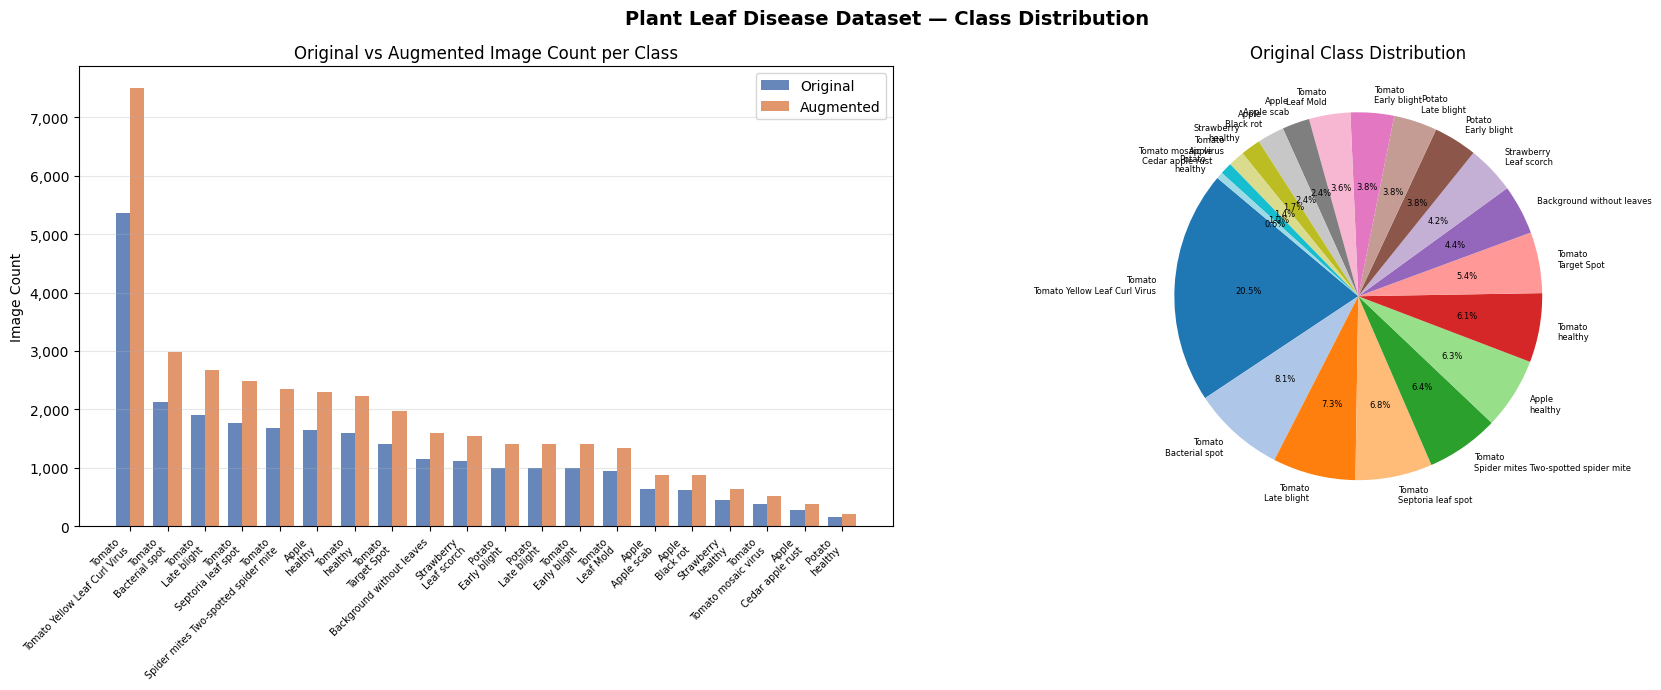

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
classes_sorted = sorted(CLASS_ORIGINAL, key=lambda x: CLASS_ORIGINAL[x], reverse=True)
orig_vals = [CLASS_ORIGINAL[c] for c in classes_sorted]
aug_vals  = [CLASS_AUGMENTED[c] for c in classes_sorted]
short     = [c.replace('___','\n').replace('_',' ') for c in classes_sorted]
x = np.arange(len(classes_sorted)); w = 0.38

axes[0].bar(x-w/2, orig_vals, w, label='Original',  color='#4C72B0', alpha=0.85)
axes[0].bar(x+w/2, aug_vals,  w, label='Augmented', color='#DD8452', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(short, rotation=45, ha='right', fontsize=7)
axes[0].set_ylabel('Image Count')
axes[0].set_title('Original vs Augmented Image Count per Class')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{int(v):,}'))

axes[1].pie(orig_vals, labels=short, autopct='%1.1f%%', startangle=140,
            textprops={'fontsize':6},
            colors=sns.color_palette('tab20', len(classes_sorted)))
axes[1].set_title('Original Class Distribution')
plt.suptitle('Plant Leaf Disease Dataset — Class Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


In [8]:
augmentation_layer = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal_and_vertical'),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
    tf.keras.layers.RandomContrast(0.2),
    tf.keras.layers.RandomBrightness(0.15),
], name='augmentation')

def preprocess_train(image, label):
    image = tf.cast(image, tf.float32)
    image = augmentation_layer(image, training=True)
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label

def preprocess_eval(image, label):
    image = tf.cast(image, tf.float32)
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label

load_kwargs = dict(image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, seed=SEED)

full_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, shuffle=True, **load_kwargs)

CLASS_NAMES   = full_ds.class_names
NUM_CLASSES   = len(CLASS_NAMES)
total_batches = tf.data.experimental.cardinality(full_ds).numpy()

val_batches   = int(total_batches * VAL_SPLIT)
test_batches  = int(total_batches * TEST_SPLIT)
train_batches = total_batches - val_batches - test_batches

train_ds_raw = full_ds.take(train_batches)
val_ds_raw   = full_ds.skip(train_batches).take(val_batches)
test_ds_raw  = full_ds.skip(train_batches + val_batches)

train_ds = (train_ds_raw
            .map(preprocess_train, num_parallel_calls=AUTOTUNE)
            .cache().shuffle(2000).prefetch(AUTOTUNE))
val_ds   = (val_ds_raw
            .map(preprocess_eval, num_parallel_calls=AUTOTUNE)
            .cache().prefetch(AUTOTUNE))
test_ds  = (test_ds_raw
            .map(preprocess_eval, num_parallel_calls=AUTOTUNE)
            .cache().prefetch(AUTOTUNE))

STEPS_PER_EPOCH = train_batches
print(f'Classes: {NUM_CLASSES} | Train: {train_batches} batches | Val: {val_batches} | Test: {test_batches}')
print(f'Class names: {CLASS_NAMES}')


I0000 00:00:1780054928.568119      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780054928.574145      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 26191 files belonging to 20 classes.
Classes: 20 | Train: 1229 batches | Val: 245 | Test: 163
Class names: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Background_without_leaves', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']


Found 26191 files belonging to 20 classes.


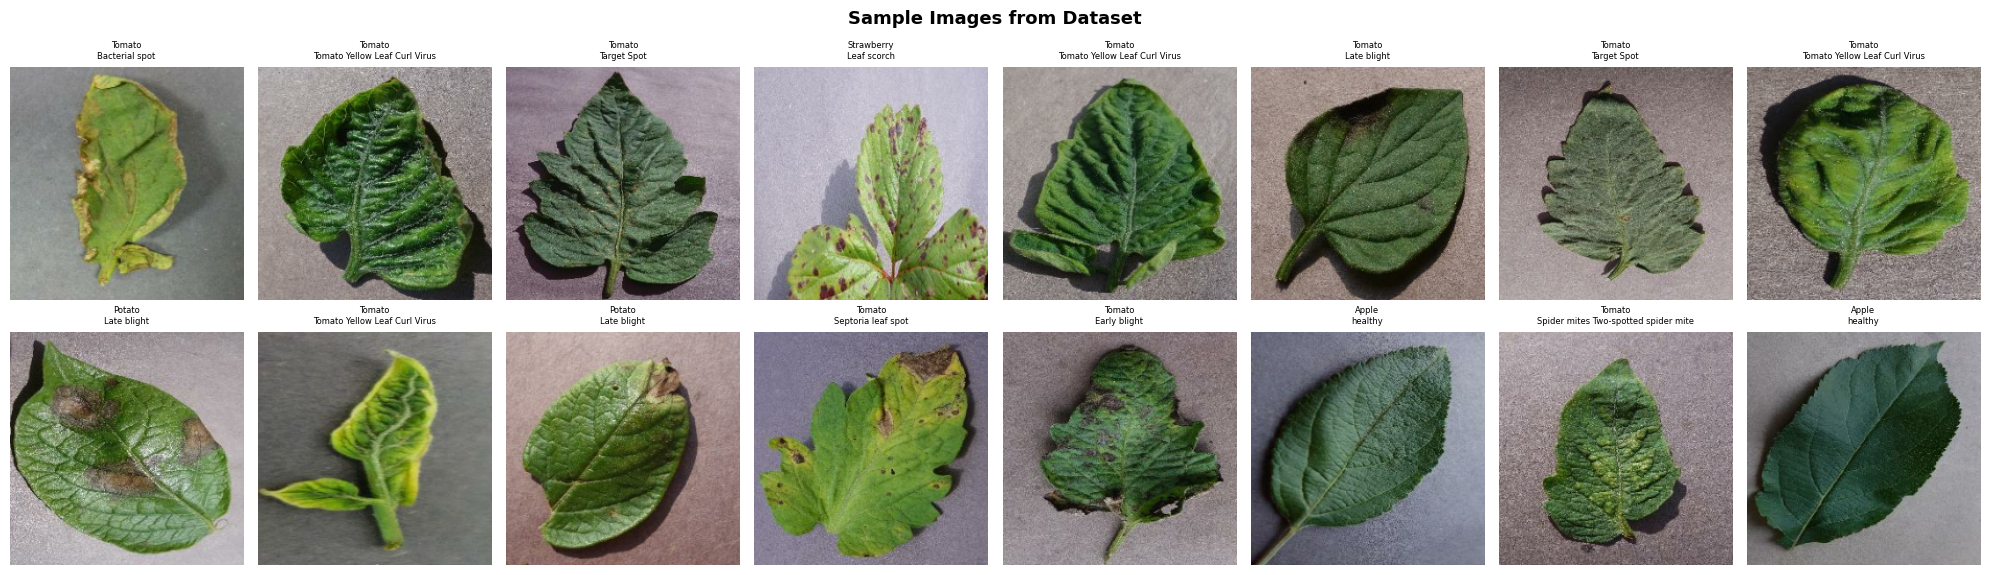

In [9]:
imgs_raw, lbls_raw = next(iter(
    tf.keras.utils.image_dataset_from_directory(
        DATA_DIR, image_size=(IMG_SIZE,IMG_SIZE), batch_size=16, seed=SEED)))
fig, axes = plt.subplots(2, 8, figsize=(20, 6))
for ax, img, lbl in zip(axes.flat, imgs_raw[:16], lbls_raw[:16]):
    ax.imshow(img.numpy().astype(np.uint8))
    ax.set_title(CLASS_NAMES[lbl].replace('___','\n').replace('_',' '), fontsize=6)
    ax.axis('off')
plt.suptitle('Sample Images from Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()


In [10]:
all_labels = []
for _, lbls in train_ds_raw:
    all_labels.extend(lbls.numpy().tolist())

unique  = np.unique(all_labels)
weights = compute_class_weight(class_weight='balanced', classes=unique, y=all_labels)
CLASS_WEIGHTS = dict(zip(unique.tolist(), weights.tolist()))

print('Class weights:')
for i, w in CLASS_WEIGHTS.items():
    print(f'  {CLASS_NAMES[i]:<50} → {w:.4f}')


Class weights:
  Apple___Apple_scab                                 → 2.0526
  Apple___Black_rot                                  → 2.1328
  Apple___Cedar_apple_rust                           → 4.6160
  Apple___healthy                                    → 0.7961
  Background_without_leaves                          → 1.1224
  Potato___Early_blight                              → 1.3377
  Potato___Late_blight                               → 1.3269
  Potato___healthy                                   → 8.6246
  Strawberry___Leaf_scorch                           → 1.1860
  Strawberry___healthy                               → 2.8011
  Tomato___Bacterial_spot                            → 0.6013
  Tomato___Early_blight                              → 1.3162
  Tomato___Late_blight                               → 0.6842
  Tomato___Leaf_Mold                                 → 1.3751
  Tomato___Septoria_leaf_spot                        → 0.7261
  Tomato___Spider_mites Two-spotted_spider_mite      → 

In [11]:
def build_model(num_classes, trainable_backbone=False):
    backbone = tf.keras.applications.MobileNetV2(
        input_shape=IMG_SHAPE, include_top=False,
        pooling='avg', weights='imagenet')
    backbone.trainable = trainable_backbone

    inputs = tf.keras.Input(shape=IMG_SHAPE)
    x = backbone(inputs, training=trainable_backbone)
    x = tf.keras.layers.Dropout(0.4)(x)
    x = tf.keras.layers.Dense(
            512, kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    x = tf.keras.layers.Dense(
            256, kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    outputs = tf.keras.layers.Dense(
            num_classes, activation='softmax', dtype='float32')(x)
    return tf.keras.Model(inputs, outputs, name='plant_mobilenetv2')

model = build_model(NUM_CLASSES, trainable_backbone=False)
trainable = sum(tf.size(v).numpy() for v in model.trainable_variables)
total     = model.count_params()
print(f'Total params     : {total:,}')
print(f'Trainable params : {trainable:,}  ({100*trainable/total:.1f}%)')
model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total params     : 3,053,396
Trainable params : 793,876  (26.0%)


Model: "plant_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 20)             │         5,140 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,053,396 (11.65 MB)

 Trainable params: 793,876 (3.03 MB)

 Non-trainable params: 2,259,520 (8.62 MB)

In [12]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=P1_LR),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name='acc')],
)

p1_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        os.path.join(CHECKPOINT_DIR, 'p1_best.keras'),
        monitor='val_acc', save_best_only=True, mode='max', verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    tf.keras.callbacks.CSVLogger('/kaggle/working/p1_log.csv'),
]

print(f'Phase 1: training head only — {P1_EPOCHS} epochs ...')
history_p1 = model.fit(
    train_ds, validation_data=val_ds,
    epochs=P1_EPOCHS, class_weight=CLASS_WEIGHTS,
    callbacks=p1_callbacks, verbose=1)
print(f'Phase 1 best val_acc: {max(history_p1.history["val_acc"])*100:.2f}%')

Phase 1: training head only — 20 epochs ...
Epoch 1/20


I0000 00:00:1780055168.326895     133 service.cc:152] XLA service 0x7c4f34011680 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780055168.326952     133 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780055168.326959     133 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780055169.658768     133 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1780055189.450286     133 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1224/1229 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.5578 - loss: 1.5749
Epoch 1: val_acc improved from None to 0.78240, saving model to /kaggle/working/checkpoints/p1_best.keras

Epoch 1: finished saving model to /kaggle/working/checkpoints/p1_best.keras
1229/1229 ━━━━━━━━━━━━━━━━━━━━ 269s 35ms/step - acc: 0.6511 - loss: 1.2038 - val_acc: 0.7824 - val_loss: 0.7972 - learning_rate: 0.0010
Epoch 2/20
1224/1229 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.7404 - loss: 0.8879
Epoch 2: val_acc improved from 0.78240 to 0.82168, saving model to /kaggle/working/checkpoints/p1_best.keras

Epoch 2: finished saving model to /kaggle/working/checkpoints/p1_best.keras
1229/1229 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - acc: 0.7453 - loss: 0.8963 - val_acc: 0.8217 - val_loss: 0.7233 - learning_rate: 0.0010
Epoch 3/20
1229/1229 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.7649 - loss: 0.8298
Epoch 3: val_acc improved from 0.82168 to 0.85306, saving model to /kaggle/working/checkpoints/p1_best.keras

Epoch 3: fin

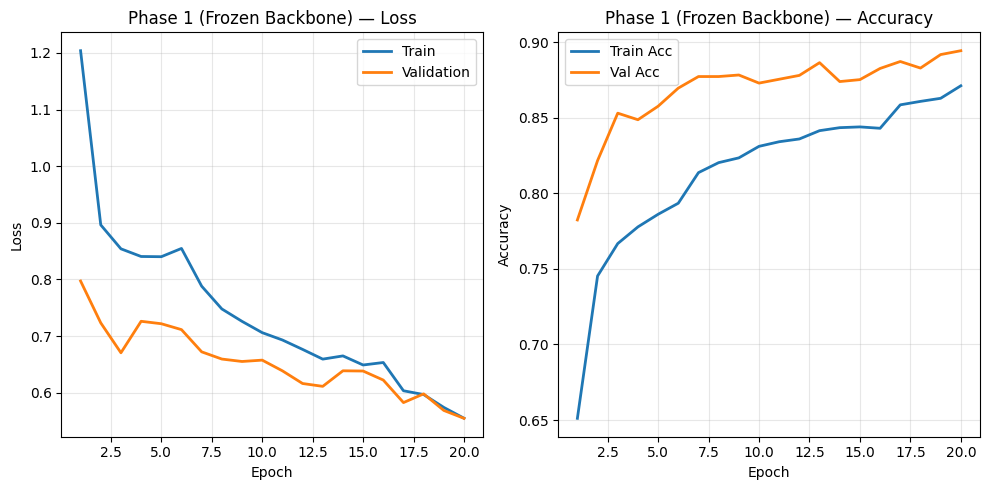

In [13]:
def plot_history(hist, title, save_path=None):
    has_pr = 'precision' in hist

    cols = 3 if has_pr else 2
    fig, axes = plt.subplots(1, cols, figsize=(cols * 5, 5))
    ep = range(1, len(hist['loss']) + 1)

    axes[0].plot(ep, hist['loss'],     label='Train', linewidth=2)
    axes[0].plot(ep, hist['val_loss'], label='Validation', linewidth=2)
    axes[0].set_title(f'{title} — Loss')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(ep, hist['acc'],     label='Train Acc', linewidth=2)
    axes[1].plot(ep, hist['val_acc'], label='Val Acc',   linewidth=2)
    axes[1].set_title(f'{title} — Accuracy')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    if has_pr:
        axes[2].plot(ep, hist['precision'],     label='Train Precision', linewidth=2)
        axes[2].plot(ep, hist['val_precision'], label='Val Precision',   linewidth=2)
        axes[2].plot(ep, hist['recall'],        label='Train Recall',    linewidth=2, linestyle='--')
        axes[2].plot(ep, hist['val_recall'],    label='Val Recall',      linewidth=2, linestyle='--')
        axes[2].set_title(f'{title} — Precision & Recall')
        axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Score')
        axes[2].legend(fontsize=7); axes[2].grid(alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

plot_history(history_p1.history, 'Phase 1 (Frozen Backbone)',
             '/kaggle/working/phase1_curves.png')

In [14]:
backbone = model.layers[1]
backbone.trainable = True
for layer in backbone.layers[:-UNFREEZE_TOP]:
    layer.trainable = False

trainable = sum(tf.size(v).numpy() for v in model.trainable_variables)
total     = model.count_params()
print(f'Unfrozen top {UNFREEZE_TOP} backbone layers')
print(f'Trainable: {trainable:,}  ({100*trainable/total:.1f}%)')


Unfrozen top 100 backbone layers
Trainable: 2,956,116  (96.8%)


In [15]:
model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=P2_LR,
        weight_decay=WEIGHT_DECAY,
        clipnorm=1.0,
    ),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name='acc')],
)

p2_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        BEST_MODEL_PATH, monitor='val_acc',
        save_best_only=True, mode='max', verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5,
        min_lr=1e-8, verbose=1),
    tf.keras.callbacks.CSVLogger('/kaggle/working/p2_log.csv'),
]

print(f'Phase 2: fine-tuning top {UNFREEZE_TOP} layers — {P2_EPOCHS} epochs ...')
history_p2 = model.fit(
    train_ds, validation_data=val_ds,
    epochs=P2_EPOCHS, class_weight=CLASS_WEIGHTS,
    callbacks=p2_callbacks, verbose=1)
print(f'Phase 2 best val_acc: {max(history_p2.history["val_acc"])*100:.2f}%')

Phase 2: fine-tuning top 100 layers — 80 epochs ...
Epoch 1/80
1229/1229 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - acc: 0.7698 - loss: 1.1087
Epoch 1: val_acc improved from None to 0.89821, saving model to /kaggle/working/plant_best_model.keras

Epoch 1: finished saving model to /kaggle/working/plant_best_model.keras
1229/1229 ━━━━━━━━━━━━━━━━━━━━ 129s 31ms/step - acc: 0.8278 - loss: 0.7860 - val_acc: 0.8982 - val_loss: 0.5260 - learning_rate: 5.0000e-05
Epoch 2/80
1228/1229 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - acc: 0.9327 - loss: 0.4055
Epoch 2: val_acc did not improve from 0.89821
1229/1229 ━━━━━━━━━━━━━━━━━━━━ 24s 20ms/step - acc: 0.9349 - loss: 0.4018 - val_acc: 0.8903 - val_loss: 0.5568 - learning_rate: 5.0000e-05
Epoch 3/80
1228/1229 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - acc: 0.9690 - loss: 0.3084
Epoch 3: val_acc did not improve from 0.89821
1229/1229 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - acc: 0.9674 - loss: 0.3121 - val_acc: 0.8913 - val_loss: 0.5557 - learning_rate: 5.0000e-05
Epoch 4/8

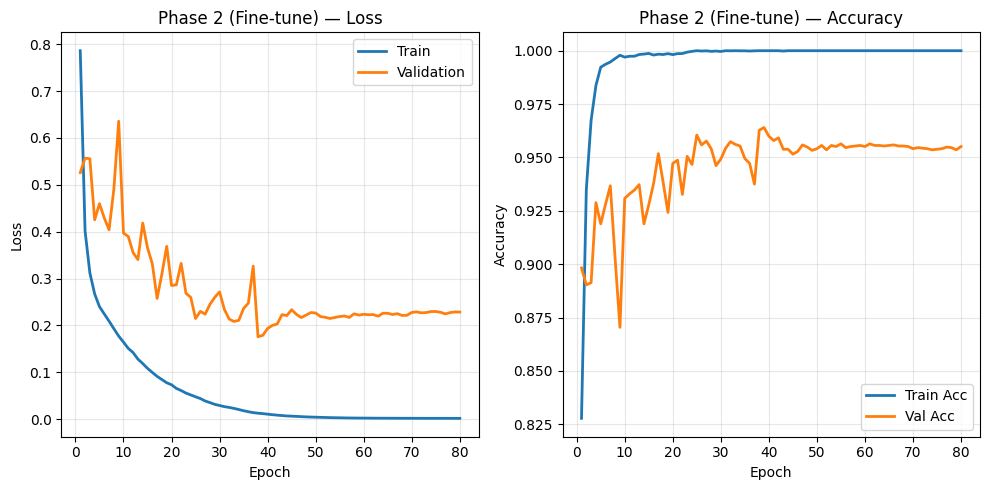

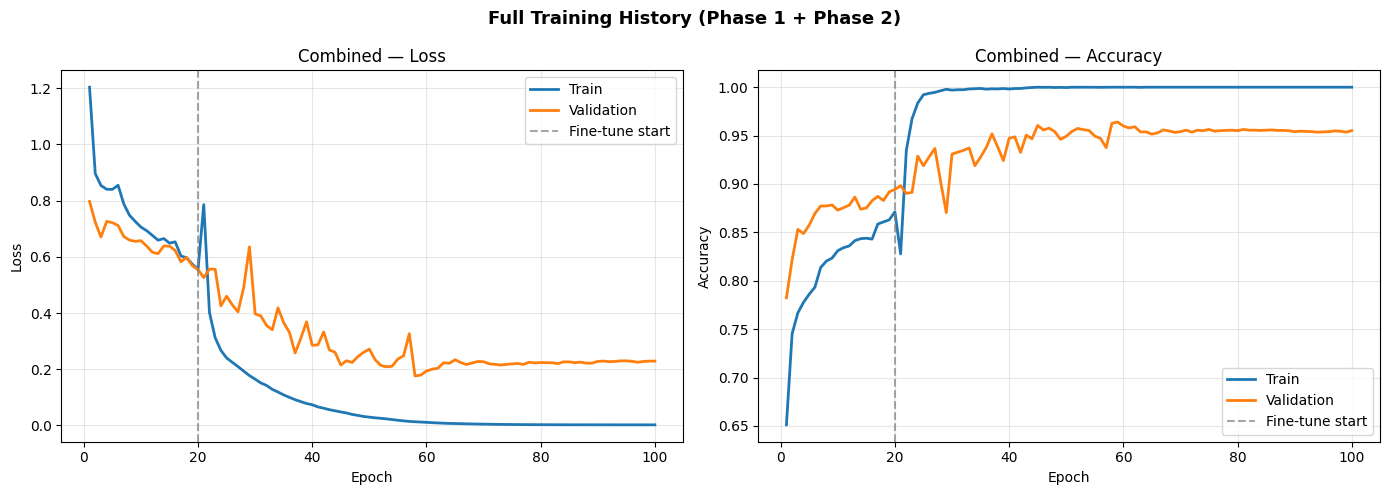

In [17]:
plot_history(history_p2.history, 'Phase 2 (Fine-tune)',
             '/kaggle/working/phase2_curves.png')

p1_len = len(history_p1.history['acc'])
ep_all = range(1, p1_len + len(history_p2.history['acc']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (tr, vl, ylabel) in zip(axes, [
        ('loss', 'val_loss', 'Loss'),
        ('acc',  'val_acc',  'Accuracy')]):
    tr_all = history_p1.history[tr] + history_p2.history[tr]
    vl_all = history_p1.history[vl] + history_p2.history[vl]
    ax.plot(ep_all, tr_all, label='Train',      linewidth=2)
    ax.plot(ep_all, vl_all, label='Validation', linewidth=2)
    ax.axvline(x=p1_len, color='gray', linestyle='--',
               alpha=0.7, label='Fine-tune start')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.set_title(f'Combined — {ylabel}')
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Full Training History (Phase 1 + Phase 2)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/combined_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
model = tf.keras.models.load_model(BEST_MODEL_PATH)
results = model.evaluate(test_ds, verbose=1)
for name, val in zip(model.metrics_names, results):
    print(f'  {name}: {val:.4f}')


163/163 ━━━━━━━━━━━━━━━━━━━━ 58s 172ms/step - acc: 0.9639 - loss: 0.1506
  loss: 0.1506
  compile_metrics: 0.9639


In [19]:
y_true, y_pred, y_prob = [], [], []
for images, labels in test_ds:
    probs = model.predict(images, verbose=0)
    y_true.extend(labels.numpy().tolist())
    y_pred.extend(np.argmax(probs, axis=1).tolist())
    y_prob.extend(probs.tolist())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)
print(f'Test samples: {len(y_true)}')


Test samples: 2607


                                               precision    recall  f1-score   support

                           Apple___Apple_scab     1.0000    0.9661    0.9828        59
                            Apple___Black_rot     1.0000    1.0000    1.0000        61
                     Apple___Cedar_apple_rust     1.0000    1.0000    1.0000        20
                              Apple___healthy     0.9711    1.0000    0.9853       168
                    Background_without_leaves     0.9906    1.0000    0.9953       105
                        Potato___Early_blight     1.0000    1.0000    1.0000       114
                         Potato___Late_blight     0.9896    0.9406    0.9645       101
                             Potato___healthy     1.0000    0.8667    0.9286        15
                     Strawberry___Leaf_scorch     1.0000    1.0000    1.0000       118
                         Strawberry___healthy     0.9762    1.0000    0.9880        41
                      Tomato___Bacterial_s

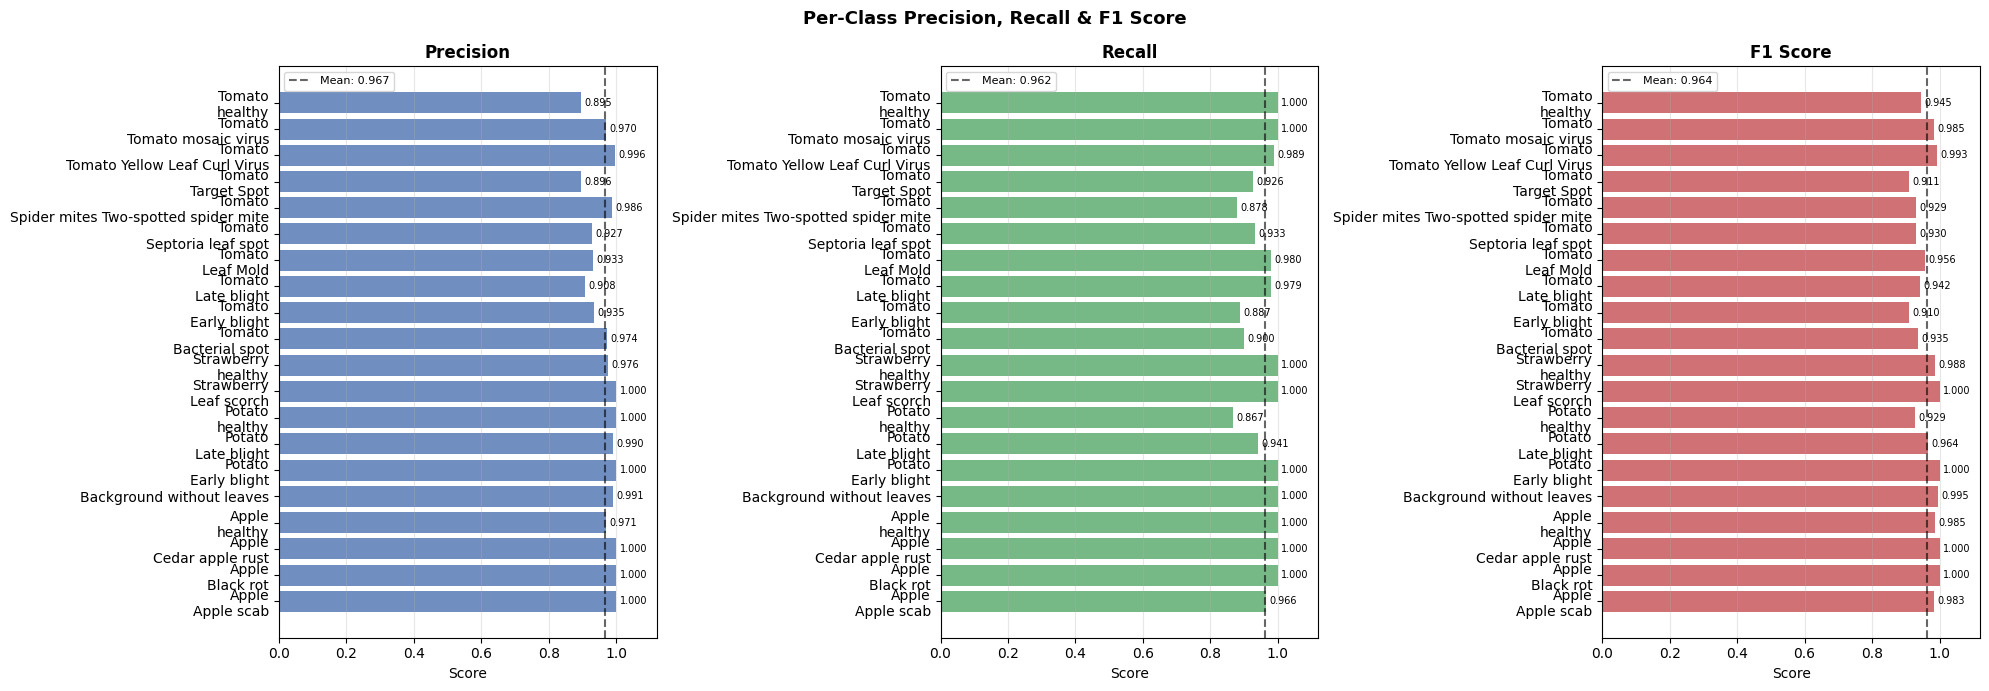

In [20]:
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred, average=None, labels=range(NUM_CLASSES))

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
short = [c.replace('___','\n').replace('_',' ') for c in CLASS_NAMES]
for ax, vals, title, color in zip(
        axes,
        [precision, recall, f1],
        ['Precision', 'Recall', 'F1 Score'],
        ['#4C72B0','#55A868','#C44E52']):
    bars = ax.barh(short, vals, color=color, alpha=0.8)
    ax.set_xlim(0, 1.12)
    ax.set_xlabel('Score')
    ax.set_title(title, fontweight='bold')
    ax.axvline(vals.mean(), color='black', linestyle='--',
               alpha=0.6, label=f'Mean: {vals.mean():.3f}')
    ax.legend(fontsize=8); ax.grid(axis='x', alpha=0.3)
    for bar, v in zip(bars, vals):
        ax.text(v+0.01, bar.get_y()+bar.get_height()/2,
                f'{v:.3f}', va='center', fontsize=7)
plt.suptitle('Per-Class Precision, Recall & F1 Score',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/precision_recall_f1.png', dpi=150, bbox_inches='tight')
plt.show()


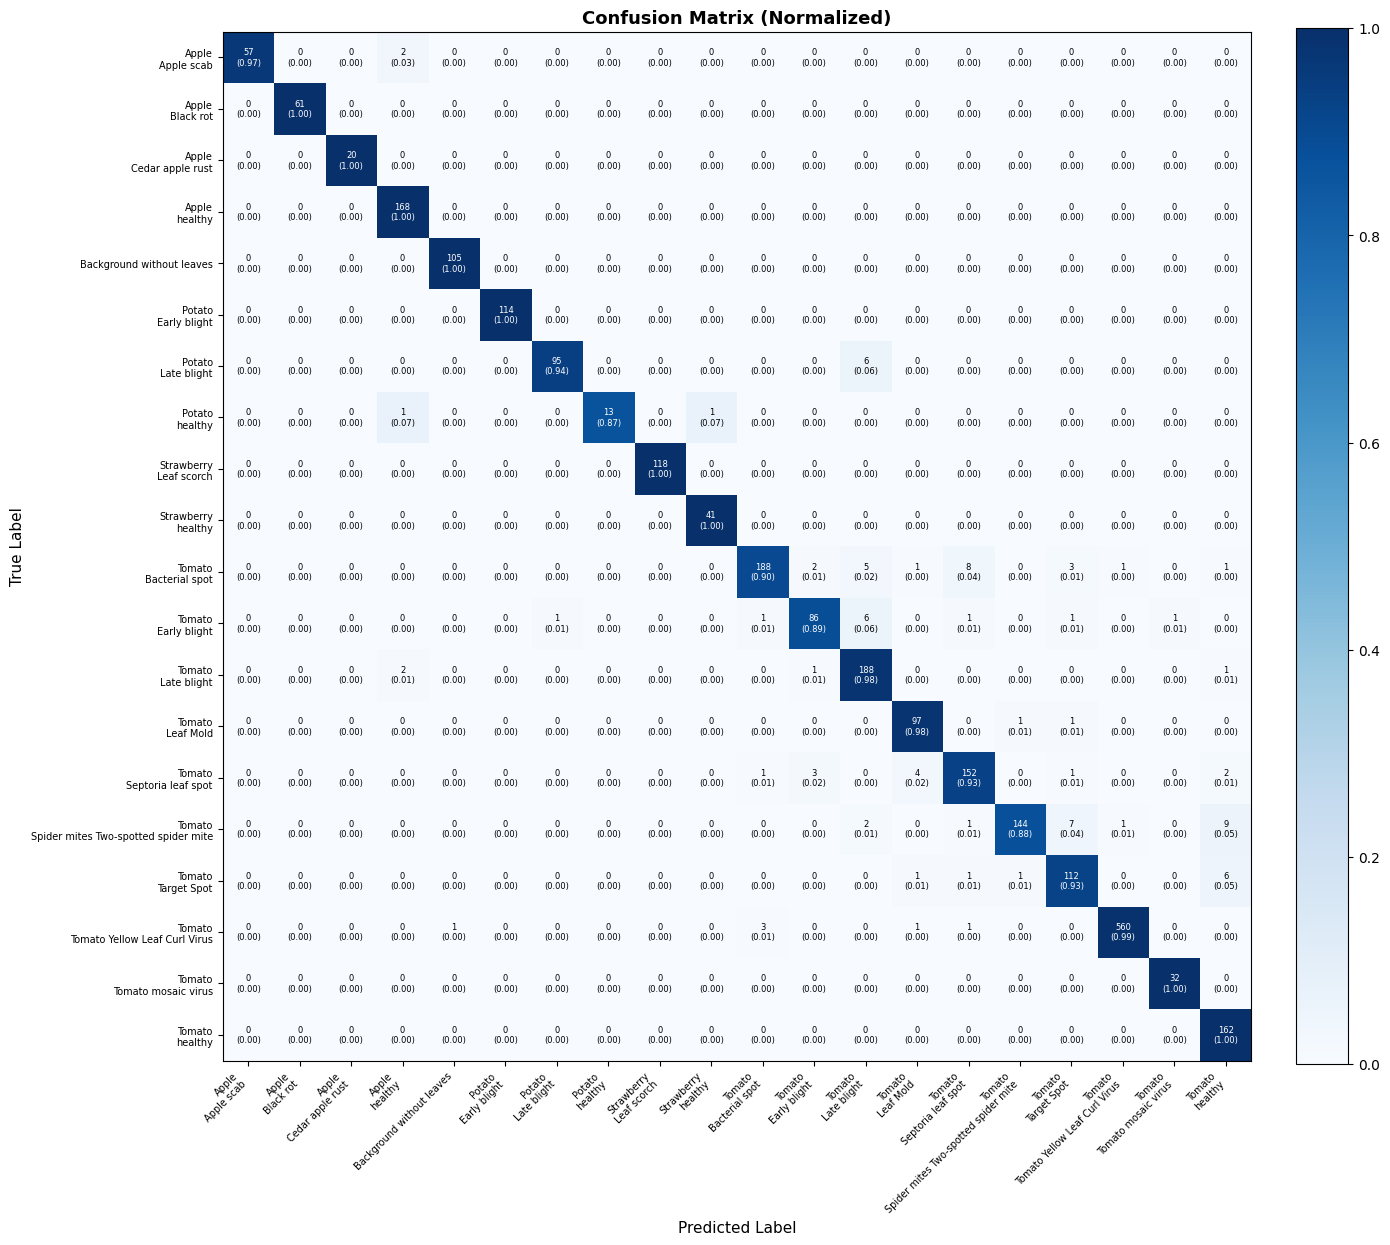

In [21]:
cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(14, 14))
im = ax.imshow(cm_norm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ticks = np.arange(NUM_CLASSES)
ax.set_xticks(ticks)
ax.set_xticklabels([c.replace('___','\n').replace('_',' ') for c in CLASS_NAMES],
                   rotation=45, ha='right', fontsize=7)
ax.set_yticks(ticks)
ax.set_yticklabels([c.replace('___','\n').replace('_',' ') for c in CLASS_NAMES],
                   fontsize=7)
for i, j in itertools.product(range(NUM_CLASSES), range(NUM_CLASSES)):
    ax.text(j, i, f'{cm[i,j]}\n({cm_norm[i,j]:.2f})',
            ha='center', va='center', fontsize=6,
            color='white' if cm_norm[i,j] > 0.5 else 'black')
ax.set_ylabel('True Label', fontsize=11)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_title('Confusion Matrix (Normalized)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


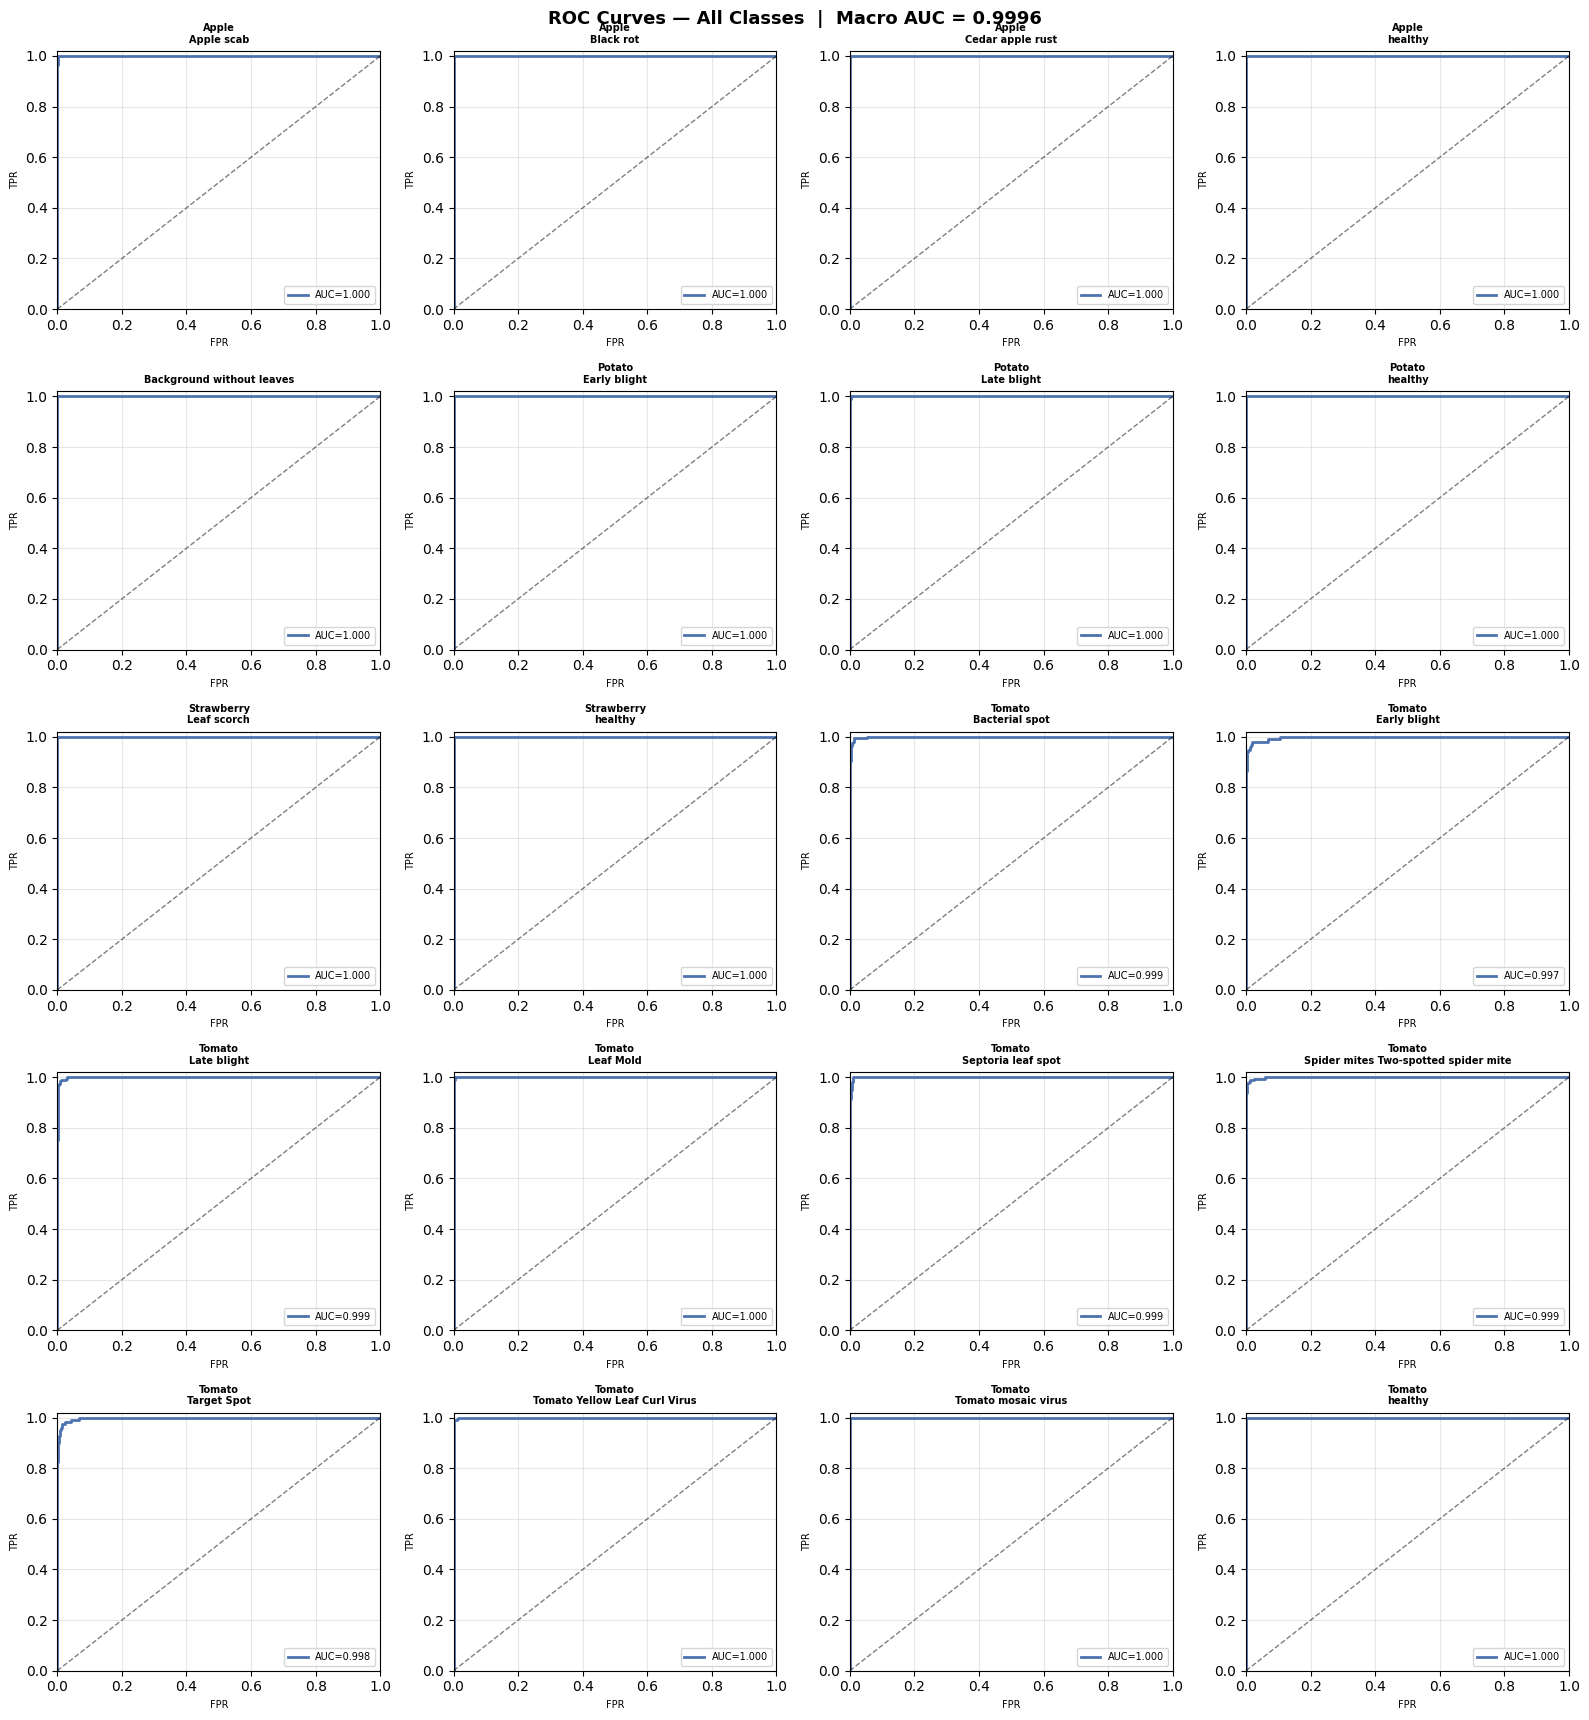

Macro AUC: 0.9996
  Apple___Apple_scab                                 AUC = 1.0000
  Apple___Black_rot                                  AUC = 1.0000
  Apple___Cedar_apple_rust                           AUC = 1.0000
  Apple___healthy                                    AUC = 1.0000
  Background_without_leaves                          AUC = 1.0000
  Potato___Early_blight                              AUC = 1.0000
  Potato___Late_blight                               AUC = 0.9999
  Potato___healthy                                   AUC = 1.0000
  Strawberry___Leaf_scorch                           AUC = 1.0000
  Strawberry___healthy                               AUC = 1.0000
  Tomato___Bacterial_spot                            AUC = 0.9991
  Tomato___Early_blight                              AUC = 0.9974
  Tomato___Late_blight                               AUC = 0.9992
  Tomato___Leaf_Mold                                 AUC = 0.9999
  Tomato___Septoria_leaf_spot                        AUC =

In [22]:
y_true_bin = label_binarize(y_true, classes=range(NUM_CLASSES))
fpr_d, tpr_d, auc_d = {}, {}, {}
for i in range(NUM_CLASSES):
    fpr_d[i], tpr_d[i], _ = roc_curve(y_true_bin[:,i], y_prob[:,i])
    auc_d[i] = auc(fpr_d[i], tpr_d[i])

all_fpr  = np.unique(np.concatenate([fpr_d[i] for i in range(NUM_CLASSES)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(NUM_CLASSES):
    mean_tpr += np.interp(all_fpr, fpr_d[i], tpr_d[i])
mean_tpr  /= NUM_CLASSES
macro_auc  = auc(all_fpr, mean_tpr)

cols = 4; rows = (NUM_CLASSES + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*3.5))
for i, ax in enumerate(axes.flat):
    if i < NUM_CLASSES:
        ax.plot(fpr_d[i], tpr_d[i], color='#4C72B0', lw=2,
                label=f'AUC={auc_d[i]:.3f}')
        ax.plot([0,1],[0,1],'k--', lw=1, alpha=0.5)
        ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
        ax.set_title(CLASS_NAMES[i].replace('___','\n').replace('_',' '),
                     fontsize=7, fontweight='bold')
        ax.legend(fontsize=7); ax.grid(alpha=0.3)
        ax.set_xlabel('FPR',fontsize=7); ax.set_ylabel('TPR',fontsize=7)
    else:
        ax.axis('off')
plt.suptitle(f'ROC Curves — All Classes  |  Macro AUC = {macro_auc:.4f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Macro AUC: {macro_auc:.4f}')
for i, name in enumerate(CLASS_NAMES):
    print(f'  {name:<50} AUC = {auc_d[i]:.4f}')


        FINAL MODEL PERFORMANCE SUMMARY
  Overall Accuracy   : 96.39%
  Macro Precision    : 0.9674
  Macro Recall       : 0.9622
  Macro F1 Score     : 0.9640
  Macro AUC-ROC      : 0.9996


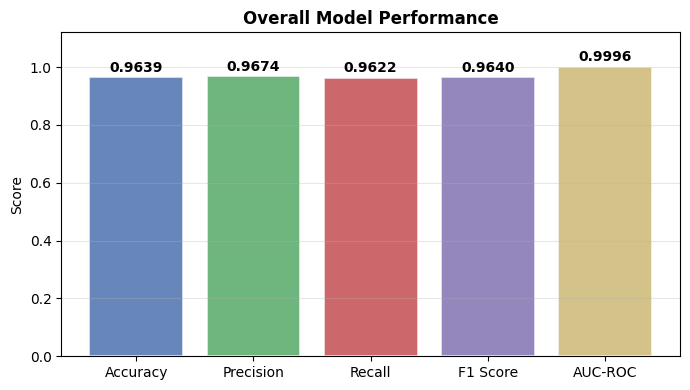

In [23]:
overall_acc = np.mean(y_true == y_pred)
macro_p = precision.mean()
macro_r = recall.mean()
macro_f = f1.mean()

print('=' * 55)
print('        FINAL MODEL PERFORMANCE SUMMARY')
print('=' * 55)
print(f'  Overall Accuracy   : {overall_acc*100:.2f}%')
print(f'  Macro Precision    : {macro_p:.4f}')
print(f'  Macro Recall       : {macro_r:.4f}')
print(f'  Macro F1 Score     : {macro_f:.4f}')
print(f'  Macro AUC-ROC      : {macro_auc:.4f}')
print('=' * 55)

fig, ax = plt.subplots(figsize=(7, 4))
metrics = ['Accuracy','Precision','Recall','F1 Score','AUC-ROC']
values  = [overall_acc, macro_p, macro_r, macro_f, macro_auc]
colors  = ['#4C72B0','#55A868','#C44E52','#8172B2','#CCB974']
bars = ax.bar(metrics, values, color=colors, alpha=0.85,
              edgecolor='white', linewidth=1.2)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('Overall Model Performance', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for bar, v in zip(bars, values):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.01,
            f'{v:.4f}', ha='center', va='bottom',
            fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/summary_metrics.png', dpi=150, bbox_inches='tight')
plt.show()


In [24]:
with open('/kaggle/working/class_names.json', 'w') as f:
    json.dump(CLASS_NAMES, f, indent=2)

artifacts = [
    BEST_MODEL_PATH,
    '/kaggle/working/class_names.json',
    '/kaggle/working/class_distribution.png',
    '/kaggle/working/phase1_curves.png',
    '/kaggle/working/phase2_curves.png',
    '/kaggle/working/combined_curves.png',
    '/kaggle/working/confusion_matrix.png',
    '/kaggle/working/roc_curves.png',
    '/kaggle/working/precision_recall_f1.png',
    '/kaggle/working/summary_metrics.png',
]
print('Saved artifacts:')
for f in artifacts:
    size = os.path.getsize(f)/1024 if os.path.exists(f) else 0
    status = '✓' if os.path.exists(f) else '✗'
    print(f'  {status}  {f}  ({size:.1f} KB)')


Saved artifacts:
  ✓  /kaggle/working/plant_best_model.keras  (58880.9 KB)
  ✓  /kaggle/working/class_names.json  (0.6 KB)
  ✓  /kaggle/working/class_distribution.png  (235.6 KB)
  ✓  /kaggle/working/phase1_curves.png  (88.6 KB)
  ✓  /kaggle/working/phase2_curves.png  (101.2 KB)
  ✓  /kaggle/working/combined_curves.png  (118.5 KB)
  ✓  /kaggle/working/confusion_matrix.png  (252.8 KB)
  ✓  /kaggle/working/roc_curves.png  (337.5 KB)
  ✓  /kaggle/working/precision_recall_f1.png  (196.2 KB)
  ✓  /kaggle/working/summary_metrics.png  (33.5 KB)
